In [17]:
import torch
from torch.utils.data import DataLoader,Dataset
from torch import nn
from torchvision import datasets
from torchvision.transforms import ToTensor
import matplotlib.pyplot as plt

In [103]:
train_ds = datasets.MNIST(
    root = "data",
    train=True,
    transform=  ToTensor(),
    download = True
)
test_ds = datasets.MNIST(
    root = "data",
    train= False,
    transform = ToTensor(),
    download = True
)
train_loader = DataLoader(
    train_ds,
    batch_size=32,
    shuffle=True,
)
test_loader = DataLoader(
    test_ds,
    batch_size=32,
    shuffle=True
)


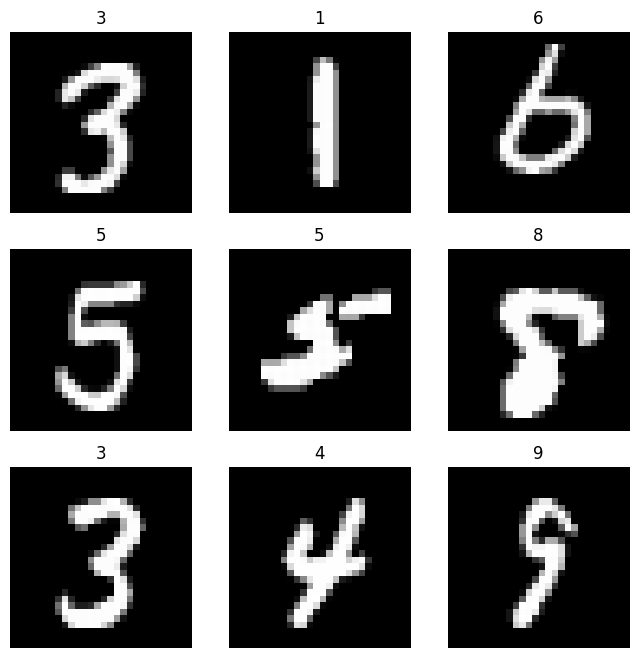

In [21]:
fig = plt.figure(figsize=(8,8))
cols,rows = 3,3

for i in range(1,cols*rows+1):
  idx = torch.randint(0,len(train_ds),size=(1,)).item()
  img,label = train_ds[idx]
  plt.subplot(rows,cols,i)
  plt.title(label)
  plt.axis('off')
  plt.imshow(img.squeeze(),cmap='gray')
plt.show()

In [58]:
from torch.nn.modules.flatten import Flatten
class MyCNN(nn.Module):
  def __init__(self):
    super().__init__()
    self.fc_shape = None
    self.relu = nn.ReLU()
    self.pool = nn.MaxPool2d(kernel_size=2,stride=2)

    self.flatten = nn.Flatten()

    self.conv1 = nn.Conv2d(1,32,kernel_size=(3,3),stride=2)
    self.conv2 = nn.Conv2d(32,64,kernel_size=(3,3),stride=2)

    dummy_x = torch.rand(28,28).view(-1,1,28,28)
    self.dim_finder(dummy_x)


    self.fc1 = nn.Linear(self.fc_shape,128)
    self.fc2 = nn.Linear(128,256)
    self.fc3 = nn.Linear(256,10)

  def dim_finder(self,x):
    if self.fc_shape == None :
      x = self.pool(self.relu(self.conv1(x)))
      x = self.pool(self.relu(self.conv2(x)))
      self.fc_shape = x[0].shape[0] * x[0].shape[1]  * x[0].shape[2]

  def forward(self,x):
    x = self.pool(self.relu(self.conv1(x)))
    x = self.pool(self.relu(self.conv2(x)))
    x = self.flatten(x)
    x = self.fc1(x)
    x = self.fc2(x)
    logits = self.fc3(x)
    return logits


In [59]:
def train_loop(model,optimizer,loss_function,dataloader):
  model.train()
  train_loss = 0.0
  for X,y in dataloader:
    optimizer.zero_grad()

    preds = model(X)
    loss = loss_function(preds,y)

    loss.backward()
    optimizer.step()

    train_loss = train_loss + loss.item()
  avg_train_loss = train_loss / len(dataloader)
  return avg_train_loss

In [127]:
model = MyCNN()
loss_function = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(),lr=0.001)
epochs = 5
for epoch in range(epochs):
  train_loss = train_loop(model,optimizer,loss_function,train_loader)

  model.eval()
  with torch.no_grad():
    test_loss = 0.0
    correct = 0
    total = 0
    for X,y in test_loader:
      preds = model(X)
      loss = loss_function(preds,y)
      test_loss = test_loss + loss.item()
      predicted = preds.argmax(dim=1)
      correct = correct+(predicted==y).sum().item()
      total = total + y.size(0)
  avg_test_loss = test_loss / len(test_loader)
  accuracy = 100 * correct / total
  print(f"Epoch : {epoch+1} | training loss : {train_loss:.4f} | testing loss : {avg_test_loss:.4f} | Testing Accuracy : {accuracy}")


Epoch : 1 | training loss : 0.3227 | testing loss : 0.1344 | Testing Accuracy : 95.76
Epoch : 2 | training loss : 0.1326 | testing loss : 0.1119 | Testing Accuracy : 96.51
Epoch : 3 | training loss : 0.1038 | testing loss : 0.1310 | Testing Accuracy : 96.05
Epoch : 4 | training loss : 0.0867 | testing loss : 0.0854 | Testing Accuracy : 97.41
Epoch : 5 | training loss : 0.0768 | testing loss : 0.0995 | Testing Accuracy : 96.89


# Inference

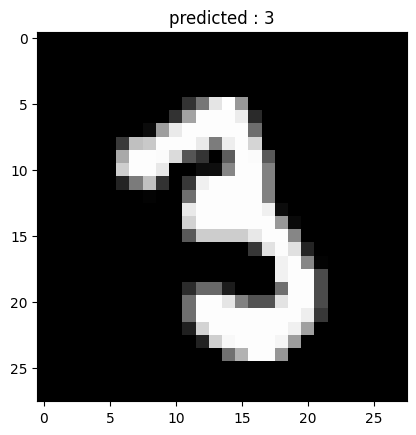

In [141]:
import matplotlib.pyplot as plt
img ,label = next(iter(test_loader))
preds = model(img)
plt.imshow(img[0].squeeze(),cmap="gray")
plt.title(f"predicted : {preds[0].argmax()}")
plt.show()